In [13]:
from risk_experiment.utils import  get_all_behavior
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = get_all_behavior(bids_folder='/data/ds-risk')

100%|██████████| 30/30 [00:03<00:00,  7.74it/s]


/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_63965/3539061673.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp = df.groupby(['subject', 'risky_first', 'bin(risky/safe)', 'bin(stake size)'])['chose_risky'].mean()


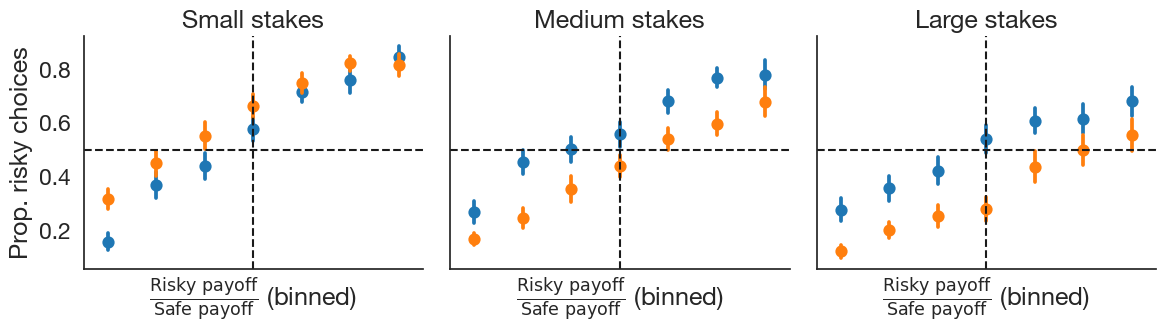

In [29]:
palette = sns.color_palette()
sns.set(style='white', font_scale=1.5, font='Helvetica Neue')
sns.set_palette(palette)

df['stake_size'] = (np.log(df['n_safe']) + np.log(df['n_risky'])) / 2.0

df['stake_size'] = df['n_safe']

df['bin(stake size)'] = pd.qcut(df['stake_size'], q=3, labels=['Small', 'Medium', 'Large'])

# df['bin(risky/safe)'] = pd.qcut(df['n_risky']/df['n_safe'], q=7)

n_bins = 7
df['bin(risky/safe)'] = df.groupby('subject').apply(lambda x: pd.qcut(x['n_risky']/x['n_safe'], q=n_bins, 
                                                                      labels=False, duplicates='drop')).reset_index(level=0, drop=True)

tmp = df.groupby(['subject', 'risky_first', 'bin(risky/safe)', 'bin(stake size)'])['chose_risky'].mean()

g = sns.catplot(x='bin(risky/safe)', y='chose_risky', data=tmp.reset_index(), kind='point', 
                hue='risky_first', col='bin(stake size)', errorbar='se', height=4., aspect=1., linestyle='none', legend=False)

g.set_titles('{col_name} stakes', fontweight='bold')

g.set(xlabel=r'$\frac{\mathrm{Risky\ payoff}}{\mathrm{Safe\ payoff}}$ (binned)', ylabel='Prop. risky choices')
g.map(plt.axhline, y=0.5, ls='--', c='k')
g.map(plt.axvline, x=(n_bins - 1)/2., ls='--', c='k')

g.set(xticks=[])

# # Change title and labels of legend to "order" and "Risky first", "Safe first"
# g._legend.set_title('Order')
# g._legend.texts[0].set_text('Safe first')
# g._legend.texts[1].set_text('Risky first')
# # g._legend.set_bbox_to_anchor((0.75, -0.18))  # right side, below axes
# # plt.tight_layout()
# plt.subplots_adjust(bottom=0.15)  # more space for legendextra space at the bottom
# g._legend.set_loc((.82, 0.18))

g.savefig('/data/ds-risk/derivatives/figures/stake_effect.pdf')

# Probit models

In [10]:
import arviz as az
import pymc as pm
import pandas as pd

idata1 = az.from_netcdf('/data/ds-risk/derivatives/cogmodels/model-probit_session_trace.netcdf')
idata2 = az.from_netcdf('/data/ds-risk/derivatives/cogmodels/model-probit_n_safe_session_trace.netcdf')
idata3 = az.from_netcdf('/data/ds-risk/derivatives/cogmodels/model-probit_order_session_trace.netcdf')
idata4 = az.from_netcdf('/data/ds-risk/derivatives/cogmodels/model-probit_full_session_trace.netcdf')


from risk_experiment.cogmodels.fit_probit import build_model
model1 = build_model('probit_session')
model2 = build_model('probit_n_safe_session')
model3 = build_model('probit_order_session')
model4 = build_model('probit_full_session')


100%|██████████| 30/30 [00:01<00:00, 28.84it/s]


In [6]:
# Get likelihood
for model, idata in zip([model1, model2, model3, model4], [idata1, idata2, idata3, idata4]):
    # Get likelihood
    model.compute_log_likelihood(idata)

In [7]:
az.compare({'probit_session': idata1, 
            'probit_n_safe_session': idata2, 
            'probit_order_session': idata3, 
            'probit_full_session': idata4}, )

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
probit_full_session,0,-5864.653118,321.734377,0.000000,0.953203,54.361303,0.000000,False,log
probit_n_safe_session,1,-6121.425916,216.162349,256.772798,0.020992,51.829342,22.916419,False,log
probit_order_session,2,-6397.758685,117.794986,533.105566,0.025805,48.566751,32.080278,False,log
probit_session,3,-6518.535749,87.843258,653.882631,0.000000,47.203812,35.108676,False,log


In [8]:
from risk_experiment.cogmodels.fit_probit import build_model, get_data
import scipy.stats as ss
import numpy as np

def invprobit(x):
    return ss.norm.ppf(x)

def get_fake_data(data, group, model_label=None):

    unique_subjects = data.index.unique(level='subject')
            # model = bambi.Model('chose_risky ~ x*risky_first*C(n_safe)  + (x*risky_first*C(n_safe)|subject)', df.reset_index(), link='probit', family='bernoulli')

    if group:
        fake_data = pd.MultiIndex.from_product([unique_subjects[:1], [0, 1], data['n_safe'].unique(), [False, True]], names=['subject', 'x', 'n_safe', 'risky_first']).to_frame(index=False)
    else:
        fake_data = pd.MultiIndex.from_product([unique_subjects, [0,1], data['n_safe'].unique(), [False, True]], names=['subject', 'x', 'n_safe', 'risky_first']).to_frame(index=False)

    if model_label == 4:
        fake_data['n_safe'] = fake_data['n_safe_bin'].apply(lambda x: np.mean(np.array(x.split('-'), dtype=float)))


    return fake_data

def extract_intercept_gamma(trace, model, data, group=False, model_label=None):

    fake_data = get_fake_data(data, group, model_label=model_label)

    pred = model.predict(trace, 'response_params', fake_data, inplace=False, include_group_specific=not group)['posterior']['p']

    pred = pred.to_dataframe().unstack([0, 1])
    pred = pred.set_index(pd.MultiIndex.from_frame(fake_data))

    # return pred

    pred0 = pred.xs(0, 0, 'x')
    intercept = pd.DataFrame(invprobit(pred0), index=pred0.index, columns=pred0.columns)
    gamma = invprobit(pred.xs(1, 0, 'x')) - intercept

    intercept = intercept.droplevel(0, 1)#,), keys=['intercept'], axis=1)
    gamma = gamma.droplevel(0, 1)#,), keys=['gamma'], axis=1)

    return intercept, gamma

def get_info(model_label, group=True):

    df = get_data(model_label=model_label, session=None)
    model = build_model(model_label=model_label, df=df)

    idata = az.from_netcdf(f'/data/ds-risk/derivatives/cogmodels/model-{model_label}_trace.netcdf')
    df['x'] = df['log(risky/safe)']
    print(df)
    intercept, gamma = extract_intercept_gamma(idata, model, df, group=group, model_label=model_label)
    rnp = np.clip(np.exp(intercept/gamma), 0, 1)
    rnp = rnp.stack([0, 1]).to_frame('rnp')
    intercept, gamma = intercept.stack([0, 1]).to_frame('intercept'), gamma.stack([0, 1]).to_frame('gamma')

    return pd.concat([intercept, gamma, rnp], axis=1)

In [11]:
pars = get_info('probit_full', group=True)
rnp, gamma = pars['rnp'].to_frame(), pars['gamma'].to_frame()

100%|██████████| 30/30 [00:01<00:00, 27.38it/s]


                                    rt  uncertainty  z_uncertainty  \
subject session run trial_nr                                         
02      3t2     1   1         1.096017          1.0      -1.508735   
                    2         1.324627          1.0      -1.508735   
                    3         1.224786          3.0       0.997077   
                    4         1.125724          3.0       0.997077   
                    5         1.175374          3.0       0.997077   
...                                ...          ...            ...   
32      7t2     8   188       0.574373          1.0      -0.535805   
                    189       0.424887          2.0       1.856628   
                    190       0.508297          1.0      -0.535805   
                    191       0.508506          1.0      -0.535805   
                    192       0.542275          2.0       1.856628   

                             median_split_uncertainty    n1    n2  prob1  \
subject sessi

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_47187/3661687142.py:54: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  rnp = rnp.stack([0, 1]).to_frame('rnp')
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_47187/3661687142.py:55: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  intercept, gamma = intercept.stack([0, 1]).to_frame('intercept'), gamma.stack([0, 1]).to_frame('gamma')
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_47187/3661687142.py:55: FutureWarning: The previous implementation of stack is deprecated and will be removed in a 

In [14]:
rnp = rnp.reset_index()
rnp['n_safe_bin'] = pd.qcut(rnp['n_safe'], q=3, labels=['Small', 'Medium', 'Large'])

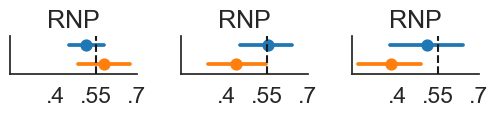

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

palette = sns.color_palette()
sns.set(style='white', font_scale=1.5)
sns.set_palette(palette)

rnp['indifference_ratio'] = 1./rnp['rnp']

def get_hdi(x, hdi_prob=0.95):
    return pd.Series(az.hdi(x.values, hdi_prob=hdi_prob), index=['hdi_lower', 'hdi_upper']).T


g = sns.FacetGrid(rnp, col='n_safe_bin', height=1.8, aspect=1., )
g.map_dataframe(sns.pointplot, x='rnp', errorbar=get_hdi, hue='risky_first', dodge=.1, hue_order=[False, True], legend=False,
                palette=sns.color_palette()[:2])

g.map(plt.axvline, x=.55, c='k', ls='--', zorder=10)
g.set(xticks=[.4, .55, .7], xlabel='', title=None, 
        yticks=[],
      yticklabels=[], ylim=(.1, -.1))

# make xtick labels slightly smaller, remove leading 0
g.set(xticklabels=['.4', '.55', '.7'])

     
g.set_titles('RNP')
# g.set(xlabel='Indifference ratio', ylabel=None, title=None)

g.savefig('/data/ds-risk/derivatives/figures/rnp_stake_effect.pdf')

In [42]:
rnp.groupby(['risky_first',     'n_safe_bin'])['rnp'].mean()

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_47187/618744183.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rnp.groupby(['risky_first',     'n_safe_bin'])['rnp'].mean()


risky_first  n_safe_bin
False        Small         0.514312
             Medium        0.553143
             Large         0.508044
True         Small         0.580764
             Medium        0.435441
             Large         0.373989
Name: rnp, dtype: float64

In [43]:
rnp.groupby(['risky_first',     'n_safe_bin'])['rnp'].apply(get_hdi)

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_47187/2267385117.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rnp.groupby(['risky_first',     'n_safe_bin'])['rnp'].apply(get_hdi)


risky_first  n_safe_bin           
False        Small       hdi_lower    0.450897
                         hdi_upper    0.578773
             Medium      hdi_lower    0.450246
                         hdi_upper    0.642540
             Large       hdi_lower    0.371533
                         hdi_upper    0.641376
True         Small       hdi_lower    0.482778
                         hdi_upper    0.676320
             Medium      hdi_lower    0.332818
                         hdi_upper    0.545648
             Large       hdi_lower    0.252705
                         hdi_upper    0.486363
Name: rnp, dtype: float64